# 00 - Benchmark & contrôle qualité du pricer V2

**Objectif** : remplacer les notebooks exploratoires par un notebook unique de contrôle permettant de comparer les versions du projet.

Ce notebook sert à :

1. reprendre les blocs utiles des anciens notebooks ;
2. intégrer les nouvelles briques : bootstrapping dépôt/FRA/swap, conventions de dates, SVI/SSVI, validation de repricing marché ;
3. produire des résultats attendus explicites pour comparer **attendu vs obtenu** ;
4. identifier rapidement les faiblesses restantes : données absentes, erreurs de pricing, calibration instable, arbitrage statique, agrégations incohérentes.

## Notebooks remplacés

| Ancien notebook | Ce qui est conservé ici |
|---|---|
| `00_architecture.ipynb` | Setup projet, imports, disponibilité des modules |
| `01_data_quality.ipynb` | Chargement des datasets, qualité des colonnes, shapes, dates |
| `02_rates.ipynb` | Courbe legacy + nouvelle courbe bootstrappée marché |
| `03_vanilla_pricing.ipynb` | Benchmarks Black-Scholes, put-call parity, Greeks |
| `04_vol_calibration.ipynb` | IV inversion, SVI/SSVI, contrôles d’arbitrage, repricing |
| `05_option_strategies.ipynb` | Décomposition/pricing des stratégies optionnelles |
| `06_structured_notes.ipynb` | Décomposition/pricing des notes structurées simples |
| `07_portfolio_risk.ipynb` | Valorisation portefeuille, agrégations, pivots de risque |

## Convention de lecture des résultats

Chaque section affiche une table de checks avec :

- `observed` : résultat obtenu par le code courant ;
- `expected` : valeur cible, tolérance ou propriété attendue ;
- `status` : `PASS`, `WARN` ou `FAIL`.

Un `FAIL` indique une incohérence à corriger. Un `WARN` indique souvent un manque de données ou un module optionnel non encore installé.

# 1. Paramètres du benchmark

Adapter uniquement cette cellule pour comparer plusieurs versions du projet.

In [43]:
from __future__ import annotations

RUN_PLOTS = True
RUN_DATA_QUALITY = True
RUN_MARKET_VOL_CALIBRATION = True
RUN_PORTFOLIO = True

# Pendant la stabilisation des modèles de volatilité, garder True.
# Objectif : valider le code sur des données contrôlées avant de revenir au marché réel.
FORCE_SYNTHETIC_VOL_PANEL = False

# Si FORCE_SYNTHETIC_VOL_PANEL=False, le notebook utilise les données marché
# quand elles sont disponibles et bascule sur du synthétique si le panel est trop pauvre.
USE_SYNTHETIC_VOL_PANEL_IF_NEEDED = True

# Afficher le détail du filtrage du panel optionnel.
SHOW_VOL_FILTER_DIAGNOSTICS = True

# Hypothèses communes de pricing pour les checks déterministes.
BASE_SPOT = 100.0
BASE_RATE = 0.05
BASE_VOL = 0.20
BASE_DIVIDEND_YIELD = 0.0
BASE_MATURITY = 1.0
BASE_STRIKE = 100.0

# Tolérances numériques.
TOL_STRICT = 1e-8
TOL_PRICE = 1e-6
TOL_RELATIVE = 1e-4

# Paramètres de calibration.
MIN_QUOTES_FOR_MARKET_VALIDATION = 20
MIN_POINTS_PER_SVI_SLICE = 5


# 2. Setup projet, imports et disponibilité des modules

**Résultat attendu**

- Le chemin `project_root` pointe vers la racine du projet.
- Les modules V1 sont disponibles.
- Les nouveaux modules avancés sont disponibles après intégration :
  - `src.conventions.day_count`
  - `src.conventions.business_day`
  - `src.rates.bootstrap`
  - `src.rates.market_instruments`
  - `src.calibration.svi`
  - `src.calibration.market_validation`
  - `src.models.smile_black_scholes`

In [44]:
from pathlib import Path
import sys
import importlib
import math
import warnings
from dataclasses import asdict, is_dataclass

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None
    RUN_PLOTS = False

from IPython.display import display

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"project_root = {project_root}")
print(f"RUN_PLOTS = {RUN_PLOTS}")


project_root = c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer
RUN_PLOTS = True


In [45]:
MODULE_STATUS: list[dict[str, str]] = []

def check_import(module_name: str, *, required: bool = True):
    try:
        module = importlib.import_module(module_name)
        MODULE_STATUS.append({
            "module": module_name,
            "required": str(required),
            "status": "PASS",
            "details": "import ok",
        })
        return module
    except Exception as exc:
        MODULE_STATUS.append({
            "module": module_name,
            "required": str(required),
            "status": "FAIL" if required else "WARN",
            "details": repr(exc),
        })
        return None

# Modules V1
check_import("src.config")
check_import("src.market.market_data")
check_import("src.models.black_scholes")
check_import("src.models.discounting_model")
check_import("src.products.vanilla_option")
check_import("src.products.zero_coupon_bond")
check_import("src.products.option_strategy")
check_import("src.products.structured_note")
check_import("src.rates.yield_curve")
check_import("src.calibration.implied_vol")
check_import("src.portfolio.book", required=False)
check_import("src.risk.report", required=False)

# Modules avancés V2
check_import("src.conventions.day_count", required=False)
check_import("src.conventions.business_day", required=False)
check_import("src.rates.market_instruments", required=False)
check_import("src.rates.bootstrap", required=False)
check_import("src.calibration.svi", required=False)
check_import("src.calibration.market_validation", required=False)
check_import("src.models.smile_black_scholes", required=False)

module_status = pd.DataFrame(MODULE_STATUS)
display(module_status)

ADVANCED_RATES_AVAILABLE = module_status.loc[
    module_status["module"].isin([
        "src.conventions.day_count",
        "src.conventions.business_day",
        "src.rates.market_instruments",
        "src.rates.bootstrap",
    ]),
    "status",
].eq("PASS").all()

ADVANCED_VOL_AVAILABLE = module_status.loc[
    module_status["module"].isin([
        "src.calibration.svi",
        "src.calibration.market_validation",
        "src.models.smile_black_scholes",
    ]),
    "status",
].eq("PASS").all()

print(f"ADVANCED_RATES_AVAILABLE = {ADVANCED_RATES_AVAILABLE}")
print(f"ADVANCED_VOL_AVAILABLE = {ADVANCED_VOL_AVAILABLE}")

,module,required,status,details
0,src.config,True,PASS,import ok
1,src.market.market_data,True,PASS,import ok
2,src.models.black_scholes,True,PASS,import ok
3,src.models.discounting_model,True,PASS,import ok
4,src.products.vanilla_option,True,PASS,import ok
5,src.products.zero_coupon_bond,True,PASS,import ok
6,src.products.option_strategy,True,PASS,import ok
7,src.products.structured_note,True,PASS,import ok
8,src.rates.yield_curve,True,PASS,import ok
9,src.calibration.implied_vol,True,PASS,import ok


ADVANCED_RATES_AVAILABLE = True
ADVANCED_VOL_AVAILABLE = True


# 3. Utilitaires de contrôle attendu/obtenu

Toutes les sections suivantes alimentent la liste `CHECKS`.

À la fin du notebook, la table de synthèse permet d’identifier ce qui casse après un refactor.

In [46]:
CHECKS: list[dict[str, object]] = []

def clear_checks(section: str | None = None) -> None:
    """Clear previous checks.

    Use clear_checks("section_name") at the beginning of a section to avoid
    stale WARN/FAIL results when rerunning individual notebook cells.
    """
    global CHECKS

    if section is None:
        CHECKS = []
        return

    CHECKS = [
        check for check in CHECKS
        if check.get("section") != section
    ]


def record_check(
    section: str,
    name: str,
    observed,
    expected: str,
    ok: bool,
    *,
    severity: str = "ERROR",
    details: str = "",
) -> None:
    CHECKS.append({
        "section": section,
        "check": name,
        "observed": observed,
        "expected": expected,
        "status": "PASS" if ok else ("WARN" if severity.upper() == "WARN" else "FAIL"),
        "details": details,
    })


def check_close(
    section: str,
    name: str,
    observed: float,
    expected_value: float,
    tolerance: float,
    *,
    severity: str = "ERROR",
) -> None:
    ok = bool(np.isfinite(observed) and abs(observed - expected_value) <= tolerance)
    record_check(
        section,
        name,
        observed,
        f"{expected_value:.12g} ± {tolerance:g}",
        ok,
        severity=severity,
        details=f"abs_error={abs(observed - expected_value):.3e}" if np.isfinite(observed) else "non finite",
    )


def check_true(
    section: str,
    name: str,
    condition: bool,
    *,
    observed=None,
    expected: str = "True",
    severity: str = "ERROR",
    details: str = "",
) -> None:
    record_check(
        section,
        name,
        condition if observed is None else observed,
        expected,
        bool(condition),
        severity=severity,
        details=details,
    )


def show_checks(section: str | None = None) -> pd.DataFrame:
    frame = pd.DataFrame(CHECKS)
    if frame.empty:
        return frame
    if section is not None:
        frame = frame[frame["section"] == section]
    status_order = {"FAIL": 0, "WARN": 1, "PASS": 2}
    return (
        frame.assign(_order=frame["status"].map(status_order))
        .sort_values(["_order", "section", "check"])
        .drop(columns="_order")
    )


def show_latest_checks(n: int = 20) -> pd.DataFrame:
    return pd.DataFrame(CHECKS).tail(n)


def result_to_dict(result) -> dict[str, float]:
    """Convert pricing/calibration result containers to a plain dict.

    This avoids relying on __dict__, which does not exist for dataclasses with slots=True.
    """
    if hasattr(result, "to_dict"):
        return dict(result.to_dict())
    if is_dataclass(result):
        return asdict(result)
    if hasattr(result, "__dict__"):
        return dict(result.__dict__)
    raise TypeError(f"Cannot convert result of type {type(result)} to dict.")


def extract_validation_metrics(validation) -> dict[str, float]:
    """Extract repricing metrics from different validation summary shapes."""
    summary = validation.summary

    if isinstance(summary, pd.DataFrame):
        if summary.empty:
            raise ValueError("validation.summary is empty.")

        # Current implementation: one-row DataFrame with columns quote_count, mae, rmse, ...
        if {"rmse", "mae"}.issubset(summary.columns):
            row = summary.iloc[0]
            return {
                "quote_count": float(row.get("quote_count", np.nan)),
                "mean_error": float(row.get("mean_error", np.nan)),
                "mae": float(row.get("mae", np.nan)),
                "rmse": float(row.get("rmse", np.nan)),
                "max_abs_error": float(row.get("max_abs_error", np.nan)),
                "mean_abs_relative_error": float(row.get("mean_abs_relative_error", np.nan)),
                "mean_abs_vol_error": float(row.get("mean_abs_vol_error", np.nan)),
            }

        # Alternative implementation: index = metric names, column = value.
        if "value" in summary.columns:
            values = summary["value"].to_dict()
            return {
                "quote_count": float(values.get("quote_count", np.nan)),
                "mean_error": float(values.get("mean_error", np.nan)),
                "mae": float(values.get("mae", values.get("mae_price_error", np.nan))),
                "rmse": float(values.get("rmse", values.get("rmse_price_error", np.nan))),
                "max_abs_error": float(values.get("max_abs_error", np.nan)),
                "mean_abs_relative_error": float(values.get("mean_abs_relative_error", np.nan)),
                "mean_abs_vol_error": float(values.get("mean_abs_vol_error", np.nan)),
            }

    if isinstance(summary, dict):
        return {
            "quote_count": float(summary.get("quote_count", np.nan)),
            "mean_error": float(summary.get("mean_error", np.nan)),
            "mae": float(summary.get("mae", summary.get("mae_price_error", np.nan))),
            "rmse": float(summary.get("rmse", summary.get("rmse_price_error", np.nan))),
            "max_abs_error": float(summary.get("max_abs_error", np.nan)),
            "mean_abs_relative_error": float(summary.get("mean_abs_relative_error", np.nan)),
            "mean_abs_vol_error": float(summary.get("mean_abs_vol_error", np.nan)),
        }

    raise TypeError(f"Unsupported validation summary type: {type(summary)}")


# 4. Imports métier

La cellule suivante importe les classes utilisées dans les tests.

**Résultat attendu**

- Aucun import V1 ne doit échouer.
- Les imports avancés peuvent être `WARN` tant que les modules ne sont pas copiés dans `src/`, mais doivent passer après intégration.

In [47]:
from src.config import ProjectConfig
from src.market.market_data import MarketData
from src.models.black_scholes import BlackScholesModel, black_scholes_price_and_greeks
from src.models.discounting_model import DiscountingModel
from src.products.vanilla_option import VanillaOption
from src.products.zero_coupon_bond import ZeroCouponBond
from src.products.option_strategy import OptionStrategy
from src.products.structured_note import (
    CapitalProtectedNote,
    CappedCapitalProtectedNote,
    ReverseConvertible,
)
from src.rates.yield_curve import YieldCurve

try:
    from src.market.loaders import load_rate_curves, load_option_quotes
except Exception as exc:
    load_rate_curves = None
    load_option_quotes = None
    warnings.warn(f"Market loaders unavailable: {exc!r}")

try:
    from src.portfolio.inventory_loader import load_inventory_workbook
except Exception:
    try:
        from src.portfolio import load_inventory_workbook
    except Exception as exc:
        load_inventory_workbook = None
        warnings.warn(f"Inventory loader unavailable: {exc!r}")

try:
    from src.calibration.implied_vol import (
        ImpliedVolSurface,
        calibrate_implied_vol_panel,
        clean_option_panel,
    )
except Exception as exc:
    ImpliedVolSurface = None
    calibrate_implied_vol_panel = None
    clean_option_panel = None
    warnings.warn(f"Implied vol tools unavailable: {exc!r}")

if ADVANCED_RATES_AVAILABLE:
    from src.conventions.business_day import BusinessCalendar
    from src.rates.market_instruments import BootstrapMarket, DepositQuote, FRAQuote, SwapQuote
    from src.rates.bootstrap import bootstrap_yield_curve

if ADVANCED_VOL_AVAILABLE:
    from src.calibration.svi import SVIVolSurface, SSVIVolSurface
    from src.calibration.market_validation import reprice_vanilla_market_quotes
    from src.models.smile_black_scholes import SmileBlackScholesModel

try:
    from src.portfolio.book import PortfolioMarketContext, PortfolioValuationEngine
    from src.risk.report import build_portfolio_risk_summary, risk_pivot_table
    PORTFOLIO_AVAILABLE = True
except Exception as exc:
    PORTFOLIO_AVAILABLE = False
    warnings.warn(f"Portfolio/risk tools unavailable: {exc!r}")

print("Imports métier terminés.")

Imports métier terminés.


# 5. Chargement et qualité des données

Cette section reprend les éléments utiles de `01_data_quality.ipynb`.

**Résultats attendus**

| Dataset | Attendu |
|---|---|
| Courbes de taux | lignes non vides, colonnes `country`, `observation_date`, `curve_tenor_years`, `rate_decimal` |
| Options | lignes non vides, colonnes `option_type`, `strike`, `underlying_price`, `time_to_maturity_years` après normalisation |
| Inventaire | au moins une feuille ou un DataFrame exploitable |

Un `WARN` ici ne bloque pas les tests déterministes : le notebook bascule sur des données synthétiques pour les contrôles modèle.

In [48]:
cfg = None
try:
    cfg = ProjectConfig.default(project_root)
except TypeError:
    cfg = ProjectConfig.default()
except Exception as exc:
    warnings.warn(f"ProjectConfig.default failed: {exc!r}")

rate_curves = None
option_quotes = None
inventory_sheets = None

def _try_load(name: str, fn, calls: list[tuple[tuple, dict]]):
    if fn is None:
        print(f"{name}: loader unavailable")
        return None
    last_exc = None
    for args, kwargs in calls:
        try:
            out = fn(*args, **kwargs)
            print(f"{name}: loaded")
            return out
        except Exception as exc:
            last_exc = exc
    print(f"{name}: not loaded -> {last_exc!r}")
    return None

if RUN_DATA_QUALITY and cfg is not None:
    rate_calls = []
    option_calls = []
    inventory_calls = []

    if hasattr(cfg, "raw_rate_curves_path"):
        rate_calls.append(((cfg.raw_rate_curves_path,), {}))
    rate_calls.append(((), {"config": cfg}))
    rate_calls.append(((), {}))

    if hasattr(cfg, "raw_options_path"):
        option_calls.append(((cfg.raw_options_path,), {}))
    option_calls.append(((), {"config": cfg}))
    option_calls.append(((), {}))

    inventory_calls.append(((), {"config": cfg}))
    inventory_calls.append(((), {}))

    rate_curves = _try_load("rate_curves", load_rate_curves, rate_calls)
    option_quotes = _try_load("option_quotes", load_option_quotes, option_calls)
    inventory_sheets = _try_load("inventory", load_inventory_workbook, inventory_calls)
else:
    print("Data quality loading skipped.")

data_summary_rows = []

if isinstance(rate_curves, pd.DataFrame):
    data_summary_rows.append({
        "dataset": "rate_curves",
        "rows": len(rate_curves),
        "columns": len(rate_curves.columns),
        "min_date": rate_curves["observation_date"].min() if "observation_date" in rate_curves else pd.NaT,
        "max_date": rate_curves["observation_date"].max() if "observation_date" in rate_curves else pd.NaT,
    })
    required = {"country", "observation_date", "curve_tenor_years", "rate_decimal"}
    check_true("data_quality", "rate_curves_not_empty", len(rate_curves) > 0, observed=len(rate_curves), expected="> 0", severity="WARN")
    check_true("data_quality", "rate_curves_required_columns", required.issubset(rate_curves.columns), observed=sorted(required.intersection(rate_curves.columns)), expected=str(sorted(required)), severity="WARN")
else:
    check_true("data_quality", "rate_curves_loaded", False, observed="not loaded", expected="DataFrame", severity="WARN")

if isinstance(option_quotes, pd.DataFrame):
    data_summary_rows.append({
        "dataset": "option_quotes",
        "rows": len(option_quotes),
        "columns": len(option_quotes.columns),
        "min_date": option_quotes["valuation_date"].min() if "valuation_date" in option_quotes else pd.NaT,
        "max_date": option_quotes["valuation_date"].max() if "valuation_date" in option_quotes else pd.NaT,
    })
    check_true("data_quality", "option_quotes_not_empty", len(option_quotes) > 0, observed=len(option_quotes), expected="> 0", severity="WARN")
else:
    check_true("data_quality", "option_quotes_loaded", False, observed="not loaded", expected="DataFrame", severity="WARN")

if isinstance(inventory_sheets, dict):
    total_inventory_rows = sum(len(v) for v in inventory_sheets.values() if isinstance(v, pd.DataFrame))
    data_summary_rows.append({
        "dataset": "inventory_sheets",
        "rows": total_inventory_rows,
        "columns": np.nan,
        "min_date": pd.NaT,
        "max_date": pd.NaT,
    })
    check_true("data_quality", "inventory_loaded", total_inventory_rows > 0, observed=total_inventory_rows, expected="> 0", severity="WARN")
elif isinstance(inventory_sheets, pd.DataFrame):
    data_summary_rows.append({
        "dataset": "inventory",
        "rows": len(inventory_sheets),
        "columns": len(inventory_sheets.columns),
        "min_date": pd.NaT,
        "max_date": pd.NaT,
    })
    check_true("data_quality", "inventory_loaded", len(inventory_sheets) > 0, observed=len(inventory_sheets), expected="> 0", severity="WARN")
else:
    check_true("data_quality", "inventory_loaded", False, observed="not loaded", expected="dict or DataFrame", severity="WARN")

data_summary = pd.DataFrame(data_summary_rows)
display(data_summary)
display(show_checks("data_quality"))

rate_curves: loaded
option_quotes: loaded
inventory: loaded


,dataset,rows,columns,min_date,max_date
0,rate_curves,357978,6.0,1970-01-02,2026-02-25
1,option_quotes,10456,29.0,2026-03-02,2026-03-06
2,inventory_sheets,111,NaN,NaT,NaT


,section,check,observed,expected,status,details
3,data_quality,inventory_loaded,111,> 0,PASS,
2,data_quality,option_quotes_not_empty,10456,> 0,PASS,
0,data_quality,rate_curves_not_empty,357978,> 0,PASS,
1,data_quality,rate_curves_required_columns,"[country, curve_tenor_years, observation_date,...","['country', 'curve_tenor_years', 'observation_...",PASS,


# 6. Courbe de taux legacy : cohérence ZC / forwards

Cette section reprend `02_rates.ipynb`, mais avec des checks.

**Résultats attendus**

- `discount_factor(T)` strictement positif.
- `zero_rate(T)` fini.
- `forward_rate(start, end)` fini.
- Si les taux sont positifs, les discount factors doivent être globalement décroissants.

Cette section valide la compatibilité de la courbe existante avec `DiscountingModel` et `BlackScholesModel`.

Legacy curve selected: United States 2026-02-25


,maturity,zero_rate,discount_factor
0,0.25,0.03696,0.990803
1,0.50,0.03655,0.981891
2,1.00,0.03532,0.965296
3,2.00,0.03459,0.933159
4,5.00,0.03603,0.835145


,section,check,observed,expected,status,details
4,rates_legacy,discount_factors_positive,0.835145,min DF > 0,PASS,
6,rates_legacy,forward_1y_2y_finite,0.03386,finite,PASS,
5,rates_legacy,zero_rates_finite,"[0.03695999, 0.03655, 0.03532, 0.03459, 0.03603]",all finite,PASS,


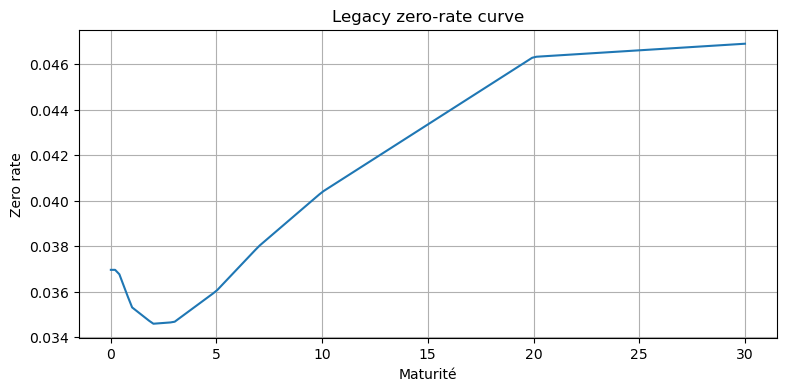

In [49]:
legacy_curve = None

if isinstance(rate_curves, pd.DataFrame) and {"country", "observation_date", "curve_tenor_years", "rate_decimal"}.issubset(rate_curves.columns):
    observation_date = rate_curves["observation_date"].max()
    country = rate_curves.loc[rate_curves["observation_date"] == observation_date, "country"].iloc[0]

    legacy_curve = YieldCurve.from_rate_curves(
        rate_curves,
        country=str(country),
        observation_date=observation_date,
        interpolation="linear",
    )
    print(f"Legacy curve selected: {legacy_curve.name}")
else:
    # Courbe synthétique simple si les données ne sont pas disponibles.
    legacy_curve = YieldCurve(
        maturities=np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0]),
        zero_rates=np.array([0.025, 0.027, 0.030, 0.032, 0.035, 0.038]),
        interpolation="linear",
        name="synthetic_legacy_curve",
    )
    print("Using synthetic legacy curve.")

grid = np.array([0.25, 0.5, 1.0, 2.0, 5.0])
curve_table = pd.DataFrame({
    "maturity": grid,
    "zero_rate": legacy_curve.zero_rate(grid),
    "discount_factor": legacy_curve.discount_factor(grid),
})
display(curve_table)

check_true("rates_legacy", "discount_factors_positive", bool((curve_table["discount_factor"] > 0).all()), observed=curve_table["discount_factor"].min(), expected="min DF > 0")
check_true("rates_legacy", "zero_rates_finite", bool(np.isfinite(curve_table["zero_rate"]).all()), observed=curve_table["zero_rate"].tolist(), expected="all finite")

fwd_1_2 = legacy_curve.forward_rate(1.0, 2.0)
check_true("rates_legacy", "forward_1y_2y_finite", np.isfinite(fwd_1_2), observed=fwd_1_2, expected="finite")

display(show_checks("rates_legacy"))

if RUN_PLOTS and plt is not None:
    dense_grid = np.linspace(0.01, float(max(legacy_curve.maturities)), 150)
    plt.figure(figsize=(9, 4))
    plt.plot(dense_grid, legacy_curve.zero_rate(dense_grid))
    plt.title("Legacy zero-rate curve")
    plt.xlabel("Maturité")
    plt.ylabel("Zero rate")
    plt.grid(True)
    plt.show()

# 7. Nouvelle courbe marché : bootstrapping dépôt / FRA / swap

Cette section valide les nouveaux modules :

- `DepositQuote`
- `FRAQuote`
- `SwapQuote`
- `bootstrap_yield_curve`
- interpolation sur discount factors / log-discount.

**Résultats attendus sur le marché synthétique**

| Check | Attendu |
|---|---|
| Nombre de points | `>= 6` |
| Discount factors | positifs |
| Courbe | non croissante si les taux sont positifs |
| ZC 5Y | prix entre 70 et 100 pour un nominal 100 et taux positifs |
| Forward 2Y→5Y | taux fini et positif |

,maturity_date,maturity_years,discount_factor,zero_rate,source,quote_rate
0,2026-05-27,0.082192,0.997506,0.030379,deposit_1M,0.0300
1,2026-07-27,0.249315,0.992225,0.031308,deposit_3M,0.0310
2,2026-10-27,0.501370,0.983994,0.032183,deposit_6M,0.0320
3,2027-01-27,0.753425,0.975765,0.032563,fra_6M_9M,0.0330
4,2027-04-27,1.000000,0.967541,0.032998,fra_9M_12M,0.0340
5,2028-04-27,2.002740,0.933465,0.034379,swap_2Y,0.0350
6,2029-04-27,3.002740,0.899193,0.035387,swap_3Y,0.0360
7,2031-04-28,5.005479,0.830045,0.037214,swap_5Y,0.0375
8,2036-04-28,10.010959,0.669072,0.040142,swap_10Y,0.0390


positive_discount_factors               True
non_increasing_discount_factors         True
min_discount_factor                 0.669072
max_discount_factor                 0.997506
point_count                              9.0
min_maturity                        0.082192
max_maturity                       10.010959
Name: bootstrap_diagnostics, dtype: object

,section,check,observed,expected,status,details
11,rates_bootstrap,forward_2y_5y_positive_finite,0.039101,finite and > 0,PASS,
9,rates_bootstrap,non_increasing_discount_factors,True,True,PASS,
7,rates_bootstrap,point_count,9,>= 6,PASS,
8,rates_bootstrap,positive_discount_factors,True,True,PASS,
10,rates_bootstrap,zc_5y_reasonable,83.0227,70 < price < 100,PASS,


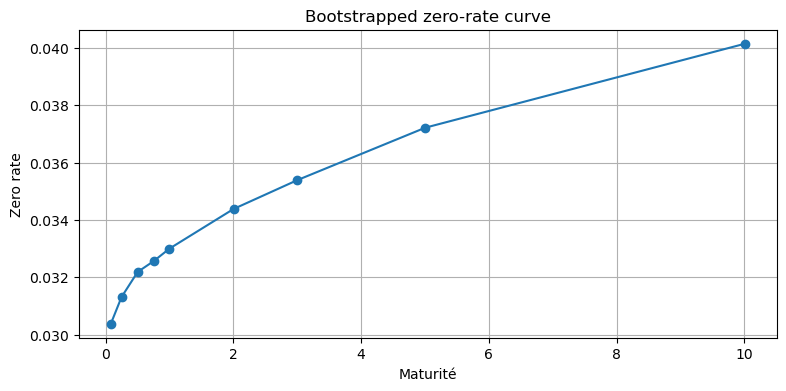

In [50]:
boot_curve = None
boot_result = None

if ADVANCED_RATES_AVAILABLE:
    bootstrap_market = BootstrapMarket(
        valuation_date=pd.Timestamp("2026-04-27"),
        calendar=BusinessCalendar(),
        deposits=(
            DepositQuote("1M", 0.0300),
            DepositQuote("3M", 0.0310),
            DepositQuote("6M", 0.0320),
        ),
        fras=(
            FRAQuote("6M", "9M", 0.0330),
            FRAQuote("9M", "12M", 0.0340),
        ),
        swaps=(
            SwapQuote("2Y", 0.0350),
            SwapQuote("3Y", 0.0360),
            SwapQuote("5Y", 0.0375),
            SwapQuote("10Y", 0.0390),
        ),
        name="EUR_synthetic_bootstrap",
    )

    boot_result = bootstrap_yield_curve(bootstrap_market)
    boot_curve = boot_result.curve

    display(boot_result.points)
    display(pd.Series(boot_result.diagnostics, name="bootstrap_diagnostics"))

    check_true("rates_bootstrap", "point_count", len(boot_result.points) >= 6, observed=len(boot_result.points), expected=">= 6")
    check_true("rates_bootstrap", "positive_discount_factors", bool(boot_result.diagnostics.get("positive_discount_factors")), observed=boot_result.diagnostics.get("positive_discount_factors"), expected="True")
    check_true("rates_bootstrap", "non_increasing_discount_factors", bool(boot_result.diagnostics.get("non_increasing_discount_factors")), observed=boot_result.diagnostics.get("non_increasing_discount_factors"), expected="True")

    zc_5y = 100.0 * boot_curve.discount_factor(5.0)
    fwd_2_5 = boot_curve.forward_rate(2.0, 5.0)
    check_true("rates_bootstrap", "zc_5y_reasonable", 70.0 < zc_5y < 100.0, observed=zc_5y, expected="70 < price < 100")
    check_true("rates_bootstrap", "forward_2y_5y_positive_finite", np.isfinite(fwd_2_5) and fwd_2_5 > 0.0, observed=fwd_2_5, expected="finite and > 0")

else:
    check_true(
        "rates_bootstrap",
        "advanced_rates_modules_available",
        False,
        observed="missing advanced rates modules",
        expected="ADVANCED_RATES_AVAILABLE=True",
        severity="WARN",
    )

display(show_checks("rates_bootstrap"))

if RUN_PLOTS and plt is not None and boot_result is not None:
    plt.figure(figsize=(9, 4))
    plt.plot(boot_result.points["maturity_years"], boot_result.points["zero_rate"], marker="o")
    plt.title("Bootstrapped zero-rate curve")
    plt.xlabel("Maturité")
    plt.ylabel("Zero rate")
    plt.grid(True)
    plt.show()

# 8. Benchmarks Black-Scholes vanille

Cette section reprend `03_vanilla_pricing.ipynb` avec des valeurs attendues connues.

Cas de référence :

- Call européen ATM
- `S = 100`, `K = 100`, `T = 1`, `r = 5%`, `sigma = 20%`, `q = 0`

**Résultats attendus**

| Métrique | Valeur attendue |
|---|---:|
| Call price | `10.4505835722` |
| Call delta | `0.6368306512` |
| Call gamma | `0.0187620173` |
| Call vega | `37.5240346917` |
| Call theta | `-6.4140275464` |
| Call rho | `53.2324815454` |

La put-call parity doit être vérifiée à `1e-8` près.

In [51]:
clear_checks("black_scholes")

market_data = MarketData(
    spot=BASE_SPOT,
    rate=BASE_RATE,
    volatility=BASE_VOL,
    dividend_yield=BASE_DIVIDEND_YIELD,
)

call = VanillaOption(
    product_id="CALL-ATM-BENCH",
    option_type="call",
    strike=BASE_STRIKE,
    maturity=BASE_MATURITY,
)

put = VanillaOption(
    product_id="PUT-ATM-BENCH",
    option_type="put",
    strike=BASE_STRIKE,
    maturity=BASE_MATURITY,
)

bs_model = BlackScholesModel()
call_result = bs_model.price_and_greeks(call, market_data)
put_result = bs_model.price_and_greeks(put, market_data)

bs_table = pd.DataFrame([
    {"product": "call", **result_to_dict(call_result)},
    {"product": "put", **result_to_dict(put_result)},
])
display(bs_table)

check_close("black_scholes", "call_price_known_value", call_result.price, 10.450583572185565, TOL_STRICT)
check_close("black_scholes", "call_delta_known_value", call_result.delta, 0.6368306511756191, TOL_STRICT)
check_close("black_scholes", "call_gamma_known_value", call_result.gamma, 0.018762017345846895, TOL_STRICT)
check_close("black_scholes", "call_vega_known_value", call_result.vega, 37.52403469169379, TOL_STRICT)
check_close("black_scholes", "call_theta_known_value", call_result.theta, -6.414027546438197, TOL_STRICT)
check_close("black_scholes", "call_rho_known_value", call_result.rho, 53.232481545376345, TOL_STRICT)

lhs = call_result.price - put_result.price
rhs = (
    BASE_SPOT * np.exp(-BASE_DIVIDEND_YIELD * BASE_MATURITY)
    - BASE_STRIKE * np.exp(-BASE_RATE * BASE_MATURITY)
)
check_close("black_scholes", "put_call_parity", lhs, rhs, TOL_STRICT)

display(show_checks("black_scholes"))


,product,price,delta,gamma,vega,theta,rho
0,call,10.450584,0.636831,0.018762,37.524035,-6.414028,53.232482
1,put,5.573526,-0.363169,0.018762,37.524035,-1.657880,-41.890461


,section,check,observed,expected,status,details
13,black_scholes,call_delta_known_value,0.636831,0.636830651176 ± 1e-08,PASS,abs_error=0.000e+00
14,black_scholes,call_gamma_known_value,0.018762,0.0187620173458 ± 1e-08,PASS,abs_error=0.000e+00
12,black_scholes,call_price_known_value,10.450584,10.4505835722 ± 1e-08,PASS,abs_error=0.000e+00
17,black_scholes,call_rho_known_value,53.232482,53.2324815454 ± 1e-08,PASS,abs_error=0.000e+00
16,black_scholes,call_theta_known_value,-6.414028,-6.41402754644 ± 1e-08,PASS,abs_error=0.000e+00
15,black_scholes,call_vega_known_value,37.524035,37.5240346917 ± 1e-08,PASS,abs_error=0.000e+00
18,black_scholes,put_call_parity,4.877058,4.87705754993 ± 1e-08,PASS,abs_error=0.000e+00


# 9. Sensibilités simples : spot, vol, taux

Objectif : vérifier que les courbes de sensibilité ont des signes cohérents.

**Résultats attendus**

- Prix du call croissant avec le spot.
- Prix du call croissant avec la volatilité.
- Vega positif.
- Gamma positif.

,section,check,observed,expected,status,details
22,sensitivities,call_gamma_positive,0.018762,> 0,PASS,
19,sensitivities,call_price_increases_with_spot,monotonic,non-decreasing,PASS,
20,sensitivities,call_price_increases_with_vol,monotonic,non-decreasing,PASS,
21,sensitivities,call_vega_positive,37.524035,> 0,PASS,


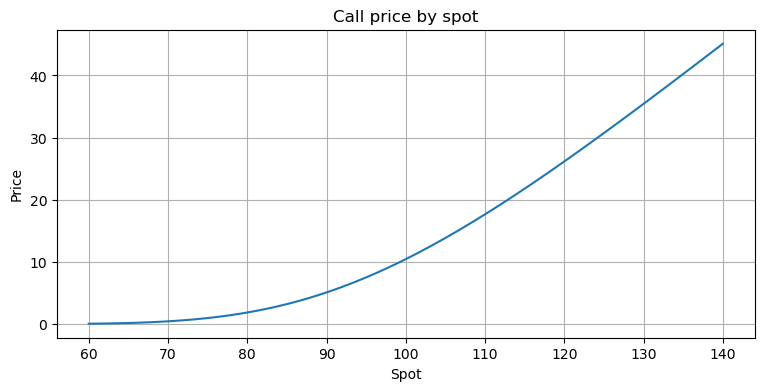

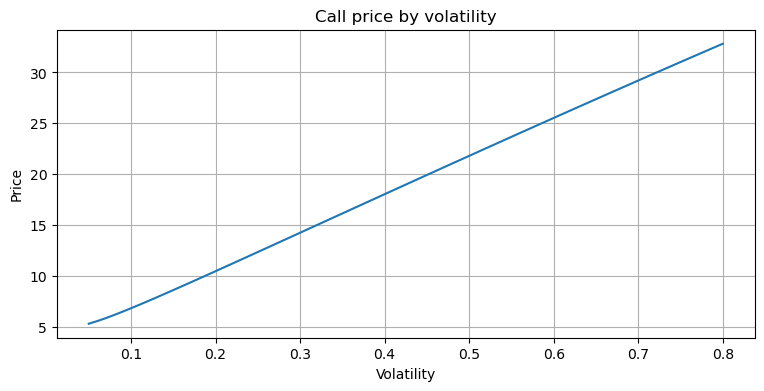

In [52]:
spot_grid = np.linspace(60.0, 140.0, 81)
vol_grid = np.linspace(0.05, 0.80, 76)

spot_sensitivity = pd.DataFrame({"spot": spot_grid})
spot_sensitivity["call_price"] = [
    bs_model.price(call, MarketData(spot=float(s), rate=BASE_RATE, volatility=BASE_VOL, dividend_yield=0.0))
    for s in spot_grid
]

vol_sensitivity = pd.DataFrame({"volatility": vol_grid})
vol_sensitivity["call_price"] = [
    BlackScholesModel(volatility=float(v), rate=BASE_RATE).price(call, MarketData(spot=BASE_SPOT, dividend_yield=0.0))
    for v in vol_grid
]

check_true("sensitivities", "call_price_increases_with_spot", bool(np.all(np.diff(spot_sensitivity["call_price"]) >= -1e-12)), observed="monotonic", expected="non-decreasing")
check_true("sensitivities", "call_price_increases_with_vol", bool(np.all(np.diff(vol_sensitivity["call_price"]) >= -1e-12)), observed="monotonic", expected="non-decreasing")
check_true("sensitivities", "call_vega_positive", call_result.vega > 0.0, observed=call_result.vega, expected="> 0")
check_true("sensitivities", "call_gamma_positive", call_result.gamma > 0.0, observed=call_result.gamma, expected="> 0")

display(show_checks("sensitivities"))

if RUN_PLOTS and plt is not None:
    plt.figure(figsize=(9, 4))
    plt.plot(spot_sensitivity["spot"], spot_sensitivity["call_price"])
    plt.title("Call price by spot")
    plt.xlabel("Spot")
    plt.ylabel("Price")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.plot(vol_sensitivity["volatility"], vol_sensitivity["call_price"])
    plt.title("Call price by volatility")
    plt.xlabel("Volatility")
    plt.ylabel("Price")
    plt.grid(True)
    plt.show()

# 10. Stratégies optionnelles : décomposition et pricing

Cette section reprend `05_option_strategies.ipynb`.

**Résultats attendus**

- Prix direct de la stratégie = somme signée des prix des jambes.
- Call spread : payoff haut ≈ `K_high - K_low`.
- Butterfly symétrique : payoff max ≈ `K_mid - K_low`.

,strategy,price,manual_sum,difference,leg_count
0,call_spread,5.051637,5.051637,0.0,2
1,put_spread,4.652818,4.652818,0.0,2
2,butterfly,1.895819,1.895819,0.0,3


,section,check,observed,expected,status,details
27,option_strategies,butterfly_max_payoff,10.0,10 ± 1e-08,PASS,abs_error=0.000e+00
25,option_strategies,butterfly_price_equals_sum_legs,1.895819,1.89581853057 ± 1e-08,PASS,abs_error=0.000e+00
26,option_strategies,call_spread_high_payoff,10.0,10 ± 1e-08,PASS,abs_error=0.000e+00
23,option_strategies,call_spread_price_equals_sum_legs,5.051637,5.0516373725 ± 1e-08,PASS,abs_error=0.000e+00
24,option_strategies,put_spread_price_equals_sum_legs,4.652818,4.65281796298 ± 1e-08,PASS,abs_error=0.000e+00


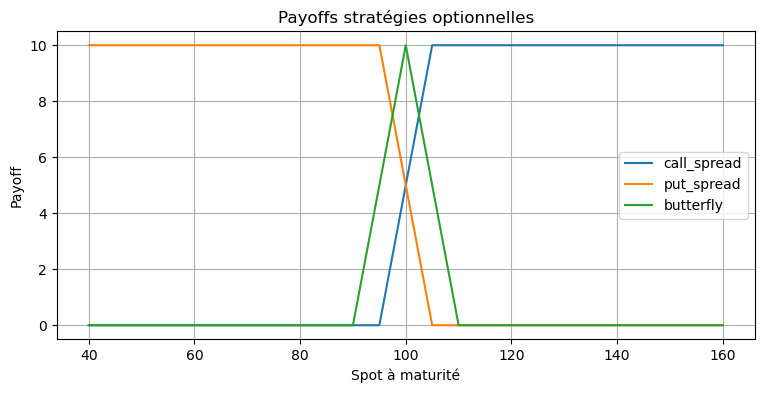

In [53]:
strategies = {
    "call_spread": OptionStrategy.call_spread(
        product_id="CS-BENCH",
        maturity=1.0,
        strike_low=95.0,
        strike_high=105.0,
    ),
    "put_spread": OptionStrategy.put_spread(
        product_id="PS-BENCH",
        maturity=1.0,
        strike_low=95.0,
        strike_high=105.0,
    ),
    "butterfly": OptionStrategy.butterfly(
        product_id="BF-BENCH",
        maturity=1.0,
        strike_low=90.0,
        strike_mid=100.0,
        strike_high=110.0,
    ),
}

strategy_md = MarketData(spot=100.0, rate=0.03, volatility=0.20, dividend_yield=0.0)
strategy_rows = []

for name, strategy in strategies.items():
    price = strategy.price(bs_model, strategy_md)
    manual = strategy.notional * sum(leg.quantity * bs_model.price(leg.product, strategy_md) for leg in strategy.legs)
    strategy_rows.append({
        "strategy": name,
        "price": price,
        "manual_sum": manual,
        "difference": price - manual,
        "leg_count": len(strategy.legs),
    })
    check_close("option_strategies", f"{name}_price_equals_sum_legs", price, manual, TOL_STRICT)

spot_grid = np.linspace(40.0, 160.0, 241)
payoff_call_spread_high = strategies["call_spread"].payoff(200.0)
check_close("option_strategies", "call_spread_high_payoff", payoff_call_spread_high, 10.0, TOL_STRICT)

butterfly_payoffs = np.array([strategies["butterfly"].payoff(float(s)) for s in spot_grid])
check_close("option_strategies", "butterfly_max_payoff", float(butterfly_payoffs.max()), 10.0, TOL_STRICT)

display(pd.DataFrame(strategy_rows))
display(show_checks("option_strategies"))

if RUN_PLOTS and plt is not None:
    plt.figure(figsize=(9, 4))
    for name, strategy in strategies.items():
        plt.plot(spot_grid, [strategy.payoff(float(s)) for s in spot_grid], label=name)
    plt.title("Payoffs stratégies optionnelles")
    plt.xlabel("Spot à maturité")
    plt.ylabel("Payoff")
    plt.grid(True)
    plt.legend()
    plt.show()

# 11. Notes structurées simples : décomposition et pricing

Cette section reprend `06_structured_notes.ipynb`.

**Résultats attendus**

- Capital protected note = ZC + call.
- Capped capital protected note = ZC + call spread.
- Reverse convertible = bond couponné - put.
- Prix de la note = somme signée des prix des jambes.

,note,label,quantity,leg_type,product_id
0,capital_protected,capital_protection_bond,1.0,ZeroCouponBond,CPN-BENCH-BOND
1,capital_protected,upside_call,1.0,VanillaOption,CPN-BENCH-CALL
2,capped_capital_protected,capital_protection_bond,1.0,ZeroCouponBond,CCPN-BENCH-BOND
3,capped_capital_protected,long_call_k1,1.0,VanillaOption,CCPN-BENCH-CALL-L
4,capped_capital_protected,short_call_k2,-1.0,VanillaOption,CCPN-BENCH-CALL-S
5,reverse_convertible,enhanced_coupon_bond,1.0,ZeroCouponBond,RC-BENCH-BOND
6,reverse_convertible,short_put,-1.0,VanillaOption,RC-BENCH-PUT-SHORT


,note,price,manual_sum,difference
0,capital_protected,106.457957,106.457957,0.0
1,capped_capital_protected,103.691399,103.691399,0.0
2,reverse_convertible,98.350161,98.350161,0.0


,section,check,observed,expected,status,details
28,structured_notes,capital_protected_price_equals_sum_legs,106.457957,106.457956739 ± 1e-08,PASS,abs_error=0.000e+00
29,structured_notes,capped_capital_protected_price_equals_sum_legs,103.691399,103.691399099 ± 1e-08,PASS,abs_error=0.000e+00
30,structured_notes,reverse_convertible_price_equals_sum_legs,98.350161,98.3501608845 ± 1e-08,PASS,abs_error=0.000e+00


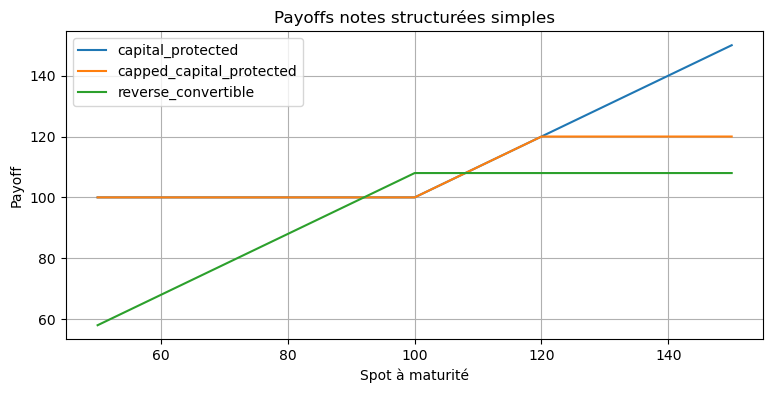

In [54]:
notes = {
    "capital_protected": CapitalProtectedNote(
        product_id="CPN-BENCH",
        notional=100.0,
        maturity=1.0,
        spot_reference=100.0,
        participation_rate=1.0,
    ),
    "capped_capital_protected": CappedCapitalProtectedNote(
        product_id="CCPN-BENCH",
        notional=100.0,
        maturity=1.0,
        spot_reference=100.0,
        cap_level=1.20,
        participation_rate=1.0,
    ),
    "reverse_convertible": ReverseConvertible(
        product_id="RC-BENCH",
        notional=100.0,
        maturity=1.0,
        spot_reference=100.0,
        coupon_rate=0.08,
    ),
}

note_md = MarketData(spot=100.0, rate=0.03, volatility=0.20, dividend_yield=0.0)
note_discount_model = DiscountingModel(rate=0.03)

decomp_rows = []
pricing_rows = []

for note_name, note in notes.items():
    legs = note.decomposition()
    for leg in legs:
        decomp_rows.append({
            "note": note_name,
            "label": leg.label,
            "quantity": leg.quantity,
            "leg_type": type(leg.product).__name__,
            "product_id": leg.product.product_id,
        })

    price = note.price(bs_model, note_discount_model, note_md)
    manual = 0.0
    for leg in legs:
        if isinstance(leg.product, VanillaOption):
            manual += leg.quantity * bs_model.price(leg.product, note_md)
        elif isinstance(leg.product, ZeroCouponBond):
            manual += leg.quantity * note_discount_model.price(leg.product, note_md)
        else:
            raise TypeError(type(leg.product))
    pricing_rows.append({"note": note_name, "price": price, "manual_sum": manual, "difference": price - manual})
    check_close("structured_notes", f"{note_name}_price_equals_sum_legs", price, manual, TOL_STRICT)

display(pd.DataFrame(decomp_rows))
display(pd.DataFrame(pricing_rows))
display(show_checks("structured_notes"))

if RUN_PLOTS and plt is not None:
    spot_grid = np.linspace(50.0, 150.0, 201)
    plt.figure(figsize=(9, 4))
    for note_name, note in notes.items():
        plt.plot(spot_grid, [note.payoff(float(s)) for s in spot_grid], label=note_name)
    plt.title("Payoffs notes structurées simples")
    plt.xlabel("Spot à maturité")
    plt.ylabel("Payoff")
    plt.grid(True)
    plt.legend()
    plt.show()

# 12. Volatilité implicite : nettoyage, inversion et panel de calibration

Cette section reprend `04_vol_calibration.ipynb`.

**Résultats attendus**

- Les quotes nettoyées ont `strike > 0`, `underlying_price > 0`, `time_to_maturity_years > 0`.
- Les volatilités implicites calibrées sont positives.
- L’erreur de repricing issue de l’inversion IV est quasi nulle sur les quotes inversibles.

Si le panel marché est insuffisant, la cellule crée un panel synthétique contrôlé pour tester les modèles de surface.

In [55]:
clear_checks("vol_iv")

def make_synthetic_option_panel(
    *,
    spot: float = 100.0,
    rate: float = 0.03,
    dividend_yield: float = 0.0,
    maturities: tuple[float, ...] = (
        1.0 / 12.0,
        0.25,
        0.5,
        1.0,
        2.0,
    ),
    log_moneyness_grid: np.ndarray | None = None,
) -> pd.DataFrame:
    """Create a stable synthetic option panel for model-code validation.

    Expected size by default:
    5 maturities × 17 strikes × 2 option types = 170 rows.
    """
    if log_moneyness_grid is None:
        log_moneyness_grid = np.linspace(-0.40, 0.40, 17)

    rows = []

    for maturity in maturities:
        for k in log_moneyness_grid:
            strike = spot * np.exp(k)

            # Smooth synthetic smile: positive, skewed, and increasing with maturity.
            implied_vol = (
                0.18
                + 0.025 * np.sqrt(maturity)
                - 0.035 * k
                + 0.08 * k * k
            )

            for option_type in ("call", "put"):
                price = black_scholes_price_and_greeks(
                    option_type=option_type,
                    spot=spot,
                    strike=float(strike),
                    maturity=float(maturity),
                    rate=rate,
                    volatility=float(implied_vol),
                    dividend_yield=dividend_yield,
                ).price

                price = max(float(price), 1e-8)

                rows.append({
                    "underlying": "SYNTH",
                    "option_type": option_type,
                    "valuation_date": pd.Timestamp("2026-04-27"),
                    "expiration_date": pd.Timestamp("2026-04-27")
                    + pd.Timedelta(days=int(365.25 * maturity)),
                    "time_to_maturity_years": float(maturity),
                    "strike": float(strike),
                    "underlying_price": float(spot),
                    "bid": price * 0.995,
                    "ask": price * 1.005,
                    "mid": price,
                    "last": price,
                    "market_price": price,
                    "true_implied_vol": float(implied_vol),
                    "moneyness": float(strike / spot),
                    "log_moneyness": float(k),
                })

    return pd.DataFrame(rows)


def ensure_vol_panel_columns(panel: pd.DataFrame) -> pd.DataFrame:
    """Ensure the option panel has the columns required for IV/SVI calibration."""
    out = panel.copy()

    out["option_type"] = (
        out["option_type"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({"c": "call", "p": "put"})
    )

    numeric_columns = [
        "strike",
        "underlying_price",
        "time_to_maturity_years",
        "bid",
        "ask",
        "mid",
        "last",
        "market_price",
        "moneyness",
        "log_moneyness",
    ]

    for col in numeric_columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "market_price" not in out.columns:
        out["market_price"] = np.nan

    if "mid" in out.columns:
        out["market_price"] = out["market_price"].fillna(out["mid"])

    if "last" in out.columns:
        out["market_price"] = out["market_price"].fillna(out["last"])

    if {"bid", "ask"}.issubset(out.columns):
        out["market_price"] = out["market_price"].fillna(
            (out["bid"] + out["ask"]) / 2.0
        )

    if "moneyness" not in out.columns:
        out["moneyness"] = out["strike"] / out["underlying_price"]

    if "log_moneyness" not in out.columns:
        out["log_moneyness"] = np.log(out["moneyness"])

    required = [
        "option_type",
        "strike",
        "underlying_price",
        "time_to_maturity_years",
        "market_price",
        "moneyness",
        "log_moneyness",
    ]

    out = out.dropna(subset=required).copy()

    return out


def filter_vol_calibration_universe(
    panel: pd.DataFrame,
    *,
    source: str,
    min_rows: int = 20,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Filter option quotes for IV/SVI calibration.

    source="synthetic" uses permissive filters.
    source="market" uses stricter liquidity/noise filters.
    """
    out = ensure_vol_panel_columns(panel)

    report: list[dict[str, object]] = []

    def add_step(name: str, frame: pd.DataFrame) -> None:
        report.append({
            "step": name,
            "rows": len(frame),
            "min_maturity": frame["time_to_maturity_years"].min() if len(frame) else np.nan,
            "max_maturity": frame["time_to_maturity_years"].max() if len(frame) else np.nan,
            "min_moneyness": frame["moneyness"].min() if len(frame) else np.nan,
            "max_moneyness": frame["moneyness"].max() if len(frame) else np.nan,
        })

    add_step("initial_after_column_cleaning", out)

    out = out[
        out["option_type"].isin(["call", "put"])
        & (out["strike"] > 0.0)
        & (out["underlying_price"] > 0.0)
        & (out["market_price"] > 0.0)
        & (out["time_to_maturity_years"] > 0.0)
        & np.isfinite(out["log_moneyness"])
    ].copy()
    add_step("basic_validity", out)

    if source == "synthetic":
        maturity_min = 7.0 / 365.25
        maturity_max = 5.0
        moneyness_min = 0.60
        moneyness_max = 1.60
        max_spread_ratio = None
    else:
        maturity_min = 14.0 / 365.25
        maturity_max = 2.5
        moneyness_min = 0.70
        moneyness_max = 1.30
        max_spread_ratio = 0.50

    out = out[
        (out["time_to_maturity_years"] >= maturity_min)
        & (out["time_to_maturity_years"] <= maturity_max)
    ].copy()
    add_step("maturity_filter", out)

    out = out[
        (out["moneyness"] >= moneyness_min)
        & (out["moneyness"] <= moneyness_max)
    ].copy()
    add_step("moneyness_filter", out)

    if max_spread_ratio is not None and {"bid", "ask"}.issubset(out.columns):
        out["bid_ask_spread_ratio"] = (out["ask"] - out["bid"]) / out["market_price"]

        out = out[
            out["bid_ask_spread_ratio"].isna()
            | (out["bid_ask_spread_ratio"] <= max_spread_ratio)
        ].copy()
        add_step("bid_ask_spread_filter", out)

    if len(out) < min_rows and source == "market":
        # Market data can be sparse/noisy; fallback is deliberately less strict.
        fallback = ensure_vol_panel_columns(panel)
        fallback = fallback[
            fallback["option_type"].isin(["call", "put"])
            & (fallback["strike"] > 0.0)
            & (fallback["underlying_price"] > 0.0)
            & (fallback["market_price"] > 0.0)
            & (fallback["time_to_maturity_years"] > 0.0)
            & (fallback["moneyness"].between(0.50, 2.00))
            & np.isfinite(fallback["log_moneyness"])
        ].copy()

        report.append({
            "step": "fallback_market_filter",
            "rows": len(fallback),
            "min_maturity": fallback["time_to_maturity_years"].min() if len(fallback) else np.nan,
            "max_maturity": fallback["time_to_maturity_years"].max() if len(fallback) else np.nan,
            "min_moneyness": fallback["moneyness"].min() if len(fallback) else np.nan,
            "max_moneyness": fallback["moneyness"].max() if len(fallback) else np.nan,
        })

        out = fallback

    return out.reset_index(drop=True), pd.DataFrame(report)


vol_source = "market"
vol_input_panel = None

if FORCE_SYNTHETIC_VOL_PANEL:
    vol_source = "synthetic"
    vol_input_panel = make_synthetic_option_panel()
elif (
    RUN_MARKET_VOL_CALIBRATION
    and isinstance(option_quotes, pd.DataFrame)
    and clean_option_panel is not None
    and calibrate_implied_vol_panel is not None
):
    try:
        candidate_clean = clean_option_panel(option_quotes)

        if len(candidate_clean) >= MIN_QUOTES_FOR_MARKET_VALIDATION:
            vol_source = "market"
            vol_input_panel = candidate_clean
        elif USE_SYNTHETIC_VOL_PANEL_IF_NEEDED:
            vol_source = "synthetic"
            vol_input_panel = make_synthetic_option_panel()
        else:
            vol_source = "market"
            vol_input_panel = candidate_clean

    except Exception as exc:
        warnings.warn(f"Market option cleaning failed, using synthetic panel: {exc!r}")
        vol_source = "synthetic"
        vol_input_panel = make_synthetic_option_panel()
else:
    vol_source = "synthetic"
    vol_input_panel = make_synthetic_option_panel()


vol_input_panel, vol_filter_report = filter_vol_calibration_universe(
    vol_input_panel,
    source=vol_source,
    min_rows=MIN_QUOTES_FOR_MARKET_VALIDATION,
)

print(f"Vol panel source: {vol_source}")
print(f"Vol panel rows after filtering: {len(vol_input_panel)}")

if SHOW_VOL_FILTER_DIAGNOSTICS:
    display(vol_filter_report)

display(vol_input_panel.head())

check_true(
    "vol_iv",
    "vol_input_panel_not_empty",
    len(vol_input_panel) > 0,
    observed=len(vol_input_panel),
    expected="> 0",
)

check_true(
    "vol_iv",
    "vol_input_panel_has_required_columns",
    {
        "option_type",
        "strike",
        "underlying_price",
        "time_to_maturity_years",
        "market_price",
    }.issubset(vol_input_panel.columns),
    observed=sorted(vol_input_panel.columns),
    expected="required vol columns present",
)

if vol_source == "synthetic":
    check_true(
        "vol_iv",
        "synthetic_panel_min_rows",
        len(vol_input_panel) >= 100,
        observed=len(vol_input_panel),
        expected=">= 100",
    )


Vol panel source: market
Vol panel rows after filtering: 4265


,step,rows,min_maturity,max_maturity,min_moneyness,max_moneyness
0,initial_after_column_cleaning,6704,0.03833,0.049281,0.007488,3.071768
1,basic_validity,6704,0.03833,0.049281,0.007488,3.071768
2,maturity_filter,6704,0.03833,0.049281,0.007488,3.071768
3,moneyness_filter,4324,0.03833,0.049281,0.700762,1.299792
4,bid_ask_spread_filter,4265,0.03833,0.049281,0.700762,1.299792


,contract_symbol,ticker,underlying,option_type,valuation_date,expiration_date,time_to_maturity_days,time_to_maturity_years,strike,bid,...,last_updated_at,delta,gamma,theta,vega,rho,market_price,moneyness,log_moneyness,bid_ask_spread_ratio
0,AAPL260320C00190000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,190.0,74.75,...,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,75.6,0.717739,-0.331649,0.022487
1,AAPL260320C00195000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,195.0,69.5,...,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,70.325,0.736627,-0.305673,0.023462
2,AAPL260320C00200000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,200.0,65.1,...,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,65.625,0.755515,-0.280355,0.016
3,AAPL260320C00205000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,205.0,59.05,...,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,60.175,0.774403,-0.255663,0.037391
4,AAPL260320C00210000,AAPL,AAPL,call,2026-03-02,2026-03-20,18,0.049281,210.0,55.2,...,2026-03-02 21:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,55.75,0.793291,-0.231565,0.019731


In [56]:
def add_iv_identifiability_columns(
    quotes: pd.DataFrame,
    *,
    rate: float,
    dividend_yield: float,
    price_column: str = "market_price",
) -> pd.DataFrame:
    """Add diagnostics to identify quotes where implied vol is numerically meaningful."""
    out = quotes.copy()

    discount_rate = np.exp(-rate * out["time_to_maturity_years"])
    discount_dividend = np.exp(-dividend_yield * out["time_to_maturity_years"])

    call_lower_bound = np.maximum(
        out["underlying_price"] * discount_dividend
        - out["strike"] * discount_rate,
        0.0,
    )

    put_lower_bound = np.maximum(
        out["strike"] * discount_rate
        - out["underlying_price"] * discount_dividend,
        0.0,
    )

    out["bs_lower_bound"] = np.where(
        out["option_type"].to_numpy() == "call",
        call_lower_bound,
        put_lower_bound,
    )

    out["time_value"] = out[price_column] - out["bs_lower_bound"]
    out["time_value_over_spot"] = out["time_value"] / out["underlying_price"]

    def row_vega(row: pd.Series) -> float:
        return black_scholes_price_and_greeks(
            option_type=str(row["option_type"]),
            spot=float(row["underlying_price"]),
            strike=float(row["strike"]),
            maturity=float(row["time_to_maturity_years"]),
            rate=rate,
            volatility=float(row["implied_vol"]),
            dividend_yield=dividend_yield,
        ).vega

    out["iv_check_vega"] = out.apply(row_vega, axis=1)

    return out

In [57]:
calibrated_quotes = None
iv_calibration_result = None

if calibrate_implied_vol_panel is not None and vol_input_panel is not None and len(vol_input_panel) > 0:
    try:
        calibrated_quotes, iv_calibration_result = calibrate_implied_vol_panel(
            vol_input_panel,
            rate=0.03,
            dividend_yield=0.0,
            price_column="market_price",
            drop_outliers=(vol_source != "synthetic"),
        )

        if calibrated_quotes is None:
            calibrated_quotes = pd.DataFrame()

        iv_summary = pd.Series({
            "source": vol_source,
            "input_rows": len(vol_input_panel),
            "calibrated_rows": len(calibrated_quotes),
            "iv_min": calibrated_quotes["implied_vol"].min() if "implied_vol" in calibrated_quotes else np.nan,
            "iv_max": calibrated_quotes["implied_vol"].max() if "implied_vol" in calibrated_quotes else np.nan,
            "calibration_objective": getattr(iv_calibration_result, "objective_value", np.nan),
        })
        display(iv_summary)

        display_columns = [
            column
            for column in [
                "option_type",
                "time_to_maturity_years",
                "strike",
                "market_price",
                "implied_vol",
                "true_implied_vol",
                "calibration_error",
            ]
            if column in calibrated_quotes.columns
        ]
        display(calibrated_quotes[display_columns].head())

        check_true(
            "vol_iv",
            "calibrated_quotes_not_empty",
            len(calibrated_quotes) > 0,
            observed=len(calibrated_quotes),
            expected="> 0",
        )

        check_true(
            "vol_iv",
            "implied_vol_positive",
            bool(len(calibrated_quotes) > 0 and (calibrated_quotes["implied_vol"] > 0).all()),
            observed=float(calibrated_quotes["implied_vol"].min()) if len(calibrated_quotes) else np.nan,
            expected="min IV > 0",
        )

        if "calibration_error" in calibrated_quotes.columns and len(calibrated_quotes):
            median_abs_error = float(calibrated_quotes["calibration_error"].abs().median())
            check_true(
                "vol_iv",
                "iv_repricing_error_small",
                median_abs_error < 1e-6,
                observed=median_abs_error,
                expected="median abs error < 1e-6",
                severity="WARN",
            )

        if vol_source == "synthetic" and "true_implied_vol" in calibrated_quotes.columns:
            calibrated_quotes = add_iv_identifiability_columns(
                calibrated_quotes,
                rate=0.03,
                dividend_yield=0.0,
                price_column="market_price",
            )

            identifiable_quotes = calibrated_quotes[
                (calibrated_quotes["iv_check_vega"] > 1e-4)
                & (calibrated_quotes["time_value_over_spot"] > 1e-8)
            ].copy()

            mean_abs_iv_error = float(
                (
                    identifiable_quotes["implied_vol"]
                    - identifiable_quotes["true_implied_vol"]
                ).abs().mean()
            )

            max_abs_iv_error = float(
                (
                    identifiable_quotes["implied_vol"]
                    - identifiable_quotes["true_implied_vol"]
                ).abs().max()
            )

            display(
                pd.Series(
                    {
                        "synthetic_quotes_total": len(calibrated_quotes),
                        "synthetic_quotes_identifiable": len(identifiable_quotes),
                        "mean_abs_iv_error_identifiable": mean_abs_iv_error,
                        "max_abs_iv_error_identifiable": max_abs_iv_error,
                        "min_vega_identifiable": identifiable_quotes["iv_check_vega"].min(),
                        "min_time_value_over_spot_identifiable": identifiable_quotes["time_value_over_spot"].min(),
                    },
                    name="synthetic_iv_recovery_diagnostics",
                )
            )

            check_true(
                "vol_iv",
                "synthetic_iv_recovered",
                mean_abs_iv_error < 1e-6,
                observed=mean_abs_iv_error,
                expected="< 1e-6 on identifiable quotes",
                severity="WARN",
            )

    except Exception as exc:
        check_true(
            "vol_iv",
            "implied_vol_calibration_success",
            False,
            observed=repr(exc),
            expected="calibration succeeds",
            severity="WARN",
        )
else:
    check_true(
        "vol_iv",
        "calibrate_implied_vol_panel_available",
        False,
        observed="missing tool or empty panel",
        expected="available and non-empty panel",
        severity="WARN",
    )

display(show_checks("vol_iv"))


source                     market
input_rows                   4265
calibrated_rows              4164
iv_min                   0.145727
iv_max                   1.017691
calibration_objective         0.0
dtype: object

,option_type,time_to_maturity_years,strike,market_price,implied_vol,calibration_error
0,call,0.049281,190.0,75.6,0.836005,-0.0
1,call,0.049281,195.0,70.325,0.699573,-0.0
2,call,0.049281,200.0,65.625,0.728201,0.0
3,call,0.049281,205.0,60.175,0.536616,-0.0
4,call,0.049281,210.0,55.75,0.642571,-0.0


,section,check,observed,expected,status,details
33,vol_iv,calibrated_quotes_not_empty,4164,> 0,PASS,
34,vol_iv,implied_vol_positive,0.145727,min IV > 0,PASS,
35,vol_iv,iv_repricing_error_small,0.0,median abs error < 1e-6,PASS,
32,vol_iv,vol_input_panel_has_required_columns,"[ask, ask_size, bid, bid_ask_spread_ratio, bid...",required vol columns present,PASS,
31,vol_iv,vol_input_panel_not_empty,4265,> 0,PASS,


# 13. SVI par maturité : calibration et contrôles d’arbitrage

Cette section valide la nouvelle surface SVI.

**Résultats attendus**

| Check | Attendu |
|---|---|
| Nombre de slices | `>= 1` |
| Variance totale minimale | `> 0` |
| Butterfly arbitrage | `True` sur la grille de diagnostic |
| Calendar arbitrage | `True` ou `WARN` selon qualité du panel |

Sur des données marché bruitées, un `WARN` en calendar/butterfly n’est pas forcément un bug de code : cela peut signaler une donnée sale, un smile mal filtré ou une calibration à contraindre davantage.

slice_count                5.000000
quote_count             4164.000000
mean_slice_objective       0.000013
Name: svi_calibration, dtype: float64

butterfly_arbitrage_free        True
calendar_arbitrage_free        False
min_butterfly_convexity     0.002953
max_total_variance          0.036263
min_total_variance           0.00334
Name: svi_diagnostics, dtype: object

,section,check,observed,expected,status,details
39,svi,calendar_arbitrage_free,False,True,WARN,
38,svi,butterfly_arbitrage_free,True,True,PASS,
37,svi,min_total_variance_positive,0.00334,> 0,PASS,
36,svi,slice_count,5.0,>= 1,PASS,


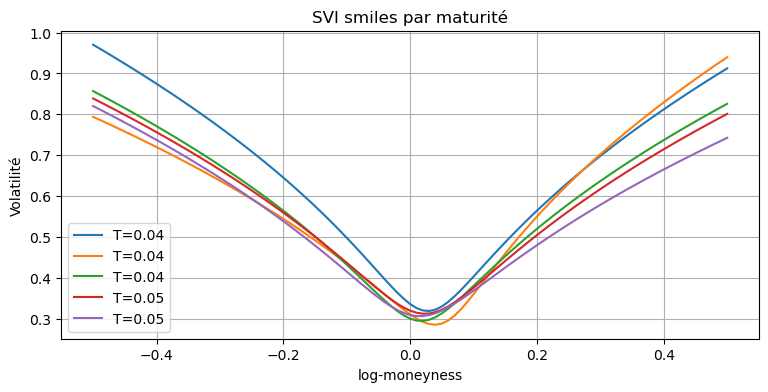

In [58]:
clear_checks("svi")

svi_surface = None
svi_validation = None

if ADVANCED_VOL_AVAILABLE and calibrated_quotes is not None and len(calibrated_quotes) > 0:
    try:
        svi_surface = SVIVolSurface.fit_from_quotes(
            calibrated_quotes,
            min_points_per_slice=MIN_POINTS_PER_SVI_SLICE,
        )
        svi_diag = svi_surface.diagnostics(log_moneyness_grid=np.linspace(-0.50, 0.50, 101))

        display(pd.Series(svi_surface.calibration.parameters, name="svi_calibration"))
        display(pd.Series(svi_diag, name="svi_diagnostics"))

        slice_count = svi_surface.calibration.parameters.get("slice_count", 0)

        check_true(
            "svi",
            "slice_count",
            slice_count >= 1,
            observed=slice_count,
            expected=">= 1",
        )

        check_true(
            "svi",
            "min_total_variance_positive",
            svi_diag["min_total_variance"] > 0.0,
            observed=svi_diag["min_total_variance"],
            expected="> 0",
        )

        check_true(
            "svi",
            "butterfly_arbitrage_free",
            bool(svi_diag["butterfly_arbitrage_free"]),
            observed=svi_diag["butterfly_arbitrage_free"],
            expected="True",
            severity="WARN",
        )

        check_true(
            "svi",
            "calendar_arbitrage_free",
            bool(svi_diag["calendar_arbitrage_free"]),
            observed=svi_diag["calendar_arbitrage_free"],
            expected="True",
            severity="WARN",
        )

    except Exception as exc:
        check_true(
            "svi",
            "svi_calibration_success",
            False,
            observed=repr(exc),
            expected="calibration succeeds",
            severity="WARN",
        )
else:
    check_true(
        "svi",
        "advanced_vol_available",
        False,
        observed="missing modules or quotes",
        expected="ADVANCED_VOL_AVAILABLE=True and calibrated_quotes not empty",
        severity="WARN",
    )

display(show_checks("svi"))

if RUN_PLOTS and plt is not None and svi_surface is not None:
    k_grid = np.linspace(-0.5, 0.5, 101)
    plt.figure(figsize=(9, 4))
    for maturity in svi_surface.maturities[: min(5, len(svi_surface.maturities))]:
        plt.plot(k_grid, svi_surface.volatility(float(maturity), k_grid), label=f"T={float(maturity):.2f}")
    plt.title("SVI smiles par maturité")
    plt.xlabel("log-moneyness")
    plt.ylabel("Volatilité")
    plt.grid(True)
    plt.legend()
    plt.show()


# 14. SSVI global : calibration et diagnostics

Cette section valide la surface paramétrique globale SSVI.

**Résultats attendus**

- Calibration réussie si le panel contient assez de strikes/maturités.
- Paramètres dans les bornes.
- Variance totale positive.
- Diagnostics d’arbitrage statique sur grille.

SSVI est plus exigeant que SVI : si la calibration échoue sur un panel marché réduit, c’est un signal de qualité/filtrage ou de nécessité de multistarts.

In [59]:
clear_checks("ssvi")

ssvi_surface = None

if ADVANCED_VOL_AVAILABLE and calibrated_quotes is not None and len(calibrated_quotes) > 0:
    try:
        ssvi_surface = SSVIVolSurface.fit_from_quotes(calibrated_quotes, max_multistarts=8)

        maturity_grid = np.array(sorted(calibrated_quotes["time_to_maturity_years"].dropna().unique()))
        if len(maturity_grid) > 6:
            maturity_grid = np.quantile(maturity_grid, np.linspace(0.0, 1.0, 6))
        if len(maturity_grid) == 0:
            maturity_grid = np.array([0.25, 0.5, 1.0, 2.0])

        ssvi_diag = ssvi_surface.diagnostics(
            maturity_grid=maturity_grid,
            log_moneyness_grid=np.linspace(-0.50, 0.50, 81),
        )

        display(pd.Series(ssvi_surface.calibration.parameters, name="ssvi_parameters"))
        display(pd.Series(ssvi_diag, name="ssvi_diagnostics"))

        check_true(
            "ssvi",
            "calibration_objective_finite",
            np.isfinite(ssvi_surface.calibration.objective_value),
            observed=ssvi_surface.calibration.objective_value,
            expected="finite",
        )

        check_true(
            "ssvi",
            "min_total_variance_positive",
            ssvi_diag["min_total_variance"] > 0.0,
            observed=ssvi_diag["min_total_variance"],
            expected="> 0",
        )

        check_true(
            "ssvi",
            "butterfly_arbitrage_free",
            bool(ssvi_diag["butterfly_arbitrage_free"]),
            observed=ssvi_diag["butterfly_arbitrage_free"],
            expected="True",
            severity="WARN",
        )

        check_true(
            "ssvi",
            "calendar_arbitrage_free",
            bool(ssvi_diag["calendar_arbitrage_free"]),
            observed=ssvi_diag["calendar_arbitrage_free"],
            expected="True",
            severity="WARN",
        )

    except Exception as exc:
        check_true(
            "ssvi",
            "ssvi_calibration_success",
            False,
            observed=repr(exc),
            expected="calibration succeeds",
            severity="WARN",
        )
else:
    check_true(
        "ssvi",
        "advanced_vol_available",
        False,
        observed="missing modules or quotes",
        expected="ADVANCED_VOL_AVAILABLE=True and calibrated_quotes not empty",
        severity="WARN",
    )

display(show_checks("ssvi"))


v0                0.089382
v_inf             0.105320
kappa             1.000429
rho              -0.101996
eta               0.574520
lambda            0.698846
quote_count    4164.000000
Name: ssvi_parameters, dtype: float64

butterfly_arbitrage_free        True
calendar_arbitrage_free        False
min_butterfly_convexity     0.002472
max_total_variance          0.033438
min_total_variance          0.003407
Name: ssvi_diagnostics, dtype: object

,section,check,observed,expected,status,details
43,ssvi,calendar_arbitrage_free,False,True,WARN,
42,ssvi,butterfly_arbitrage_free,True,True,PASS,
40,ssvi,calibration_objective_finite,0.000014,finite,PASS,
41,ssvi,min_total_variance_positive,0.003407,> 0,PASS,


In [65]:
svi_surface

SVIVolSurface(slices=(SVISlice(maturity=0.038329911019849415, params=SVIParameters(a=1e-10, b=0.0675156562907292, rho=-0.007495099591521032, m=0.02731941282513489, sigma=0.05765054512602747), objective_value=1.6373204911040244e-05, quote_count=817), SVISlice(maturity=0.04106776180698152, params=SVIParameters(a=1e-10, b=0.0636311860447127, rho=0.2709779028993309, m=0.05422557181648955, sigma=0.05451948689437139), objective_value=9.472706217126884e-06, quote_count=849), SVISlice(maturity=0.04380561259411362, params=SVIParameters(a=1e-10, b=0.06155066592207364, rho=-0.0028860572336840257, m=0.017299427912516412, sigma=0.061644933916221806), objective_value=1.2175738341489334e-05, quote_count=817), SVISlice(maturity=0.04654346338124572, params=SVIParameters(a=1e-10, b=0.0619417791719449, rho=-0.0007133328256436354, m=0.02319089160112936, sigma=0.07316708944254023), objective_value=1.2235535000135565e-05, quote_count=849), SVISlice(maturity=0.049281314168377825, params=SVIParameters(a=1e-10

identification pb

In [69]:
def diagnose_calendar_violations(
    surface,
    *,
    maturities: np.ndarray,
    log_moneyness_grid: np.ndarray,
    label: str,
    tolerance: float = 1e-10,
) -> pd.DataFrame:
    rows = []

    maturities = np.asarray(sorted(np.unique(maturities)), dtype=float)
    log_moneyness_grid = np.asarray(log_moneyness_grid, dtype=float)

    for k in log_moneyness_grid:
        vols = np.array(
            [
                surface.total_variance(float(t), float(k))
                for t in maturities
            ],
            dtype=float,
        )

        total_variance = vols**2 * maturities
        diffs = np.diff(total_variance)

        for i, diff in enumerate(diffs):
            if diff < -tolerance:
                rows.append(
                    {
                        "surface": label,
                        "log_moneyness": k,
                        "moneyness": float(np.exp(k)),
                        "t_short": maturities[i],
                        "t_long": maturities[i + 1],
                        "vol_short": vols[i],
                        "vol_long": vols[i + 1],
                        "w_short": total_variance[i],
                        "w_long": total_variance[i + 1],
                        "calendar_gap": diff,
                    }
                )

    return pd.DataFrame(rows)


if svi_surface is not None and calibrated_quotes is not None:
    maturity_grid = np.sort(calibrated_quotes["time_to_maturity_years"].unique())
    k_grid = np.linspace(-0.35, 0.35, 31)

    svi_calendar_violations = diagnose_calendar_violations(
        svi_surface,
        maturities=maturity_grid,
        log_moneyness_grid=k_grid,
        label="SVI",
    )

    print("SVI calendar violations")
    display(svi_calendar_violations.sort_values("calendar_gap").head(20))

if ssvi_surface is not None and calibrated_quotes is not None:
    ssvi_calendar_violations = diagnose_calendar_violations(
        ssvi_surface,
        maturities=maturity_grid,
        log_moneyness_grid=k_grid,
        label="SSVI",
    )

    print("SSVI calendar violations")
    display(ssvi_calendar_violations.sort_values("calendar_gap").head(20))

SVI calendar violations


,surface,log_moneyness,moneyness,t_short,t_long,vol_short,vol_long,w_short,w_long,calendar_gap
0,SVI,-0.350000,0.704688,0.038330,0.041068,0.025962,0.018984,0.000026,0.000015,-1.103341e-05
1,SVI,-0.326667,0.721324,0.038330,0.041068,0.024394,0.017916,0.000023,0.000013,-9.626009e-06
2,SVI,-0.303333,0.738353,0.038330,0.041068,0.022828,0.016850,0.000020,0.000012,-8.315479e-06
3,SVI,-0.280000,0.755784,0.038330,0.041068,0.021266,0.015785,0.000017,0.000010,-7.101814e-06
4,SVI,-0.256667,0.773626,0.038330,0.041068,0.019708,0.014724,0.000015,0.000009,-5.985009e-06
41,SVI,0.350000,1.419068,0.041068,0.043806,0.024237,0.020767,0.000024,0.000019,-5.232779e-06
5,SVI,-0.233333,0.791890,0.038330,0.041068,0.018155,0.013665,0.000013,0.000008,-4.965055e-06
39,SVI,0.326667,1.386339,0.041068,0.043806,0.022377,0.019361,0.000021,0.000016,-4.143260e-06
6,SVI,-0.210000,0.810584,0.038330,0.041068,0.016609,0.012611,0.000011,0.000007,-4.041940e-06
7,SVI,-0.186667,0.829720,0.038330,0.041068,0.015071,0.011562,0.000009,0.000005,-3.215644e-06


SSVI calendar violations


KeyError: 'calendar_gap'

La surface SVI reproduit les smiles mais ne garantit pas strictement l’absence d’arbitrage calendar. Les violations observées sont faibles et liées au bruit de marché.

# 15. Validation marché : repricer les vanilles et mesurer l’erreur modèle/prix

Cette section est la plus importante pour comparer les versions.

Elle teste :

1. surface calibrée ;
2. repricing des quotes vanilles ;
3. erreur prix modèle vs prix marché ;
4. erreur par maturité ;
5. erreur par bucket de moneyness.

**Résultats attendus**

Sur panel synthétique propre :

- RMSE faible ;
- MAE faible ;
- erreur relative moyenne faible.

Sur panel marché réel :

- l’erreur ne sera pas nulle ;
- les buckets avec erreurs élevées indiquent les zones faibles du modèle :
  - maturités courtes ;
  - options deep OTM/ITM ;
  - smiles avec peu de points ;
  - bid/ask large.

SVI validation summary


,quote_count,mean_error,mae,rmse,max_abs_error,mean_abs_relative_error,mean_abs_vol_error
0,4164.0,0.095771,0.983194,1.465727,5.575431,0.686804,0.066244


,maturity_bucket,quote_count,mean_error,mae,max_abs_error,mean_abs_relative_error,mean_abs_vol_error,rmse
0,0.04,2483,0.115094,0.980862,5.575431,0.718747,0.068877,1.474996
1,0.05,1681,0.06723,0.98664,5.482282,0.63962,0.062355,1.451928


,moneyness_bucket,quote_count,mean_error,mae,max_abs_error,mean_abs_relative_error,mean_abs_vol_error,rmse
0,deep_otm_put/itm_call,422,-0.013584,0.263151,1.233147,0.454117,0.077198,0.328997
1,otm_put/itm_call,1082,0.311768,0.791327,4.267666,0.356213,0.065714,1.066788
2,atm,1275,-0.093549,1.630067,5.575431,0.23626,0.059103,2.199990
3,otm_call/itm_put,1034,0.23888,0.840235,3.797991,1.304367,0.064486,1.114258
4,deep_otm_call/itm_put,351,-0.172468,0.511732,3.636112,1.802974,0.085826,0.780810


SSVI validation summary


,quote_count,mean_error,mae,rmse,max_abs_error,mean_abs_relative_error,mean_abs_vol_error
0,4164.0,0.085478,1.058472,1.52805,5.414003,0.739856,0.070437


,section,check,observed,expected,status,details
47,market_validation,ssvi_rmse_finite,1.52805,finite,PASS,
45,market_validation,svi_mae_finite,0.983194,finite,PASS,
46,market_validation,svi_market_rmse_observed,1.465727,monitor; no hard threshold,PASS,
44,market_validation,svi_rmse_finite,1.465727,finite,PASS,


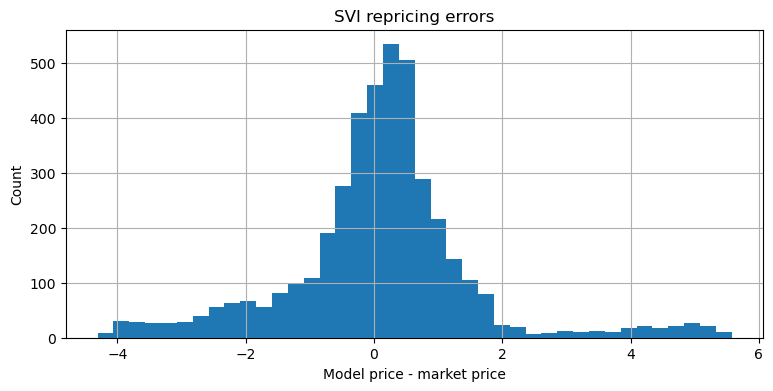

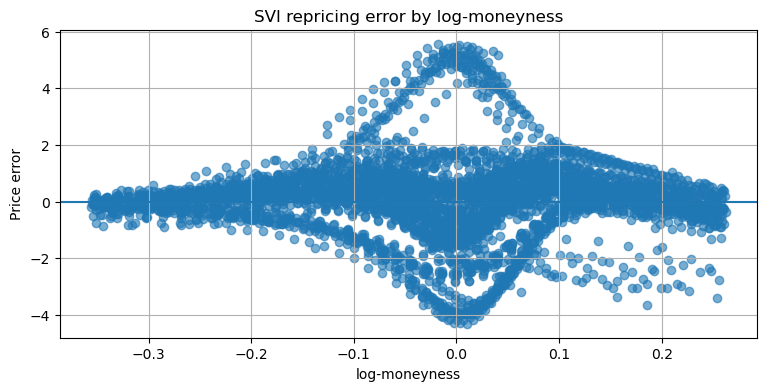

In [60]:
clear_checks("market_validation")

validation_results = {}

if ADVANCED_VOL_AVAILABLE and calibrated_quotes is not None and len(calibrated_quotes) > 0 and svi_surface is not None:
    try:
        svi_validation = reprice_vanilla_market_quotes(
            calibrated_quotes,
            svi_surface,
            rate=0.03,
            dividend_yield=0.0,
            price_column="market_price",
        )

        validation_results["SVI"] = svi_validation

        print("SVI validation summary")
        display(svi_validation.summary)
        display(svi_validation.by_maturity.head())
        display(svi_validation.by_moneyness_bucket)

        svi_metrics = extract_validation_metrics(svi_validation)

        rmse = svi_metrics["rmse"]
        mae = svi_metrics["mae"]

        check_true(
            "market_validation",
            "svi_rmse_finite",
            np.isfinite(rmse),
            observed=rmse,
            expected="finite",
        )

        check_true(
            "market_validation",
            "svi_mae_finite",
            np.isfinite(mae),
            observed=mae,
            expected="finite",
        )

        # Thresholds: strict on synthetic, observation-only on market data.
        if vol_source == "synthetic":
            check_true(
                "market_validation",
                "svi_synthetic_rmse_reasonable",
                rmse < 0.50,
                observed=rmse,
                expected="< 0.50",
            )
        else:
            check_true(
                "market_validation",
                "svi_market_rmse_observed",
                True,
                observed=rmse,
                expected="monitor; no hard threshold",
                severity="WARN",
            )

    except Exception as exc:
        check_true(
            "market_validation",
            "svi_validation_success",
            False,
            observed=repr(exc),
            expected="validation succeeds",
            severity="WARN",
        )
else:
    check_true(
        "market_validation",
        "svi_validation_available",
        False,
        observed="missing SVI surface or calibrated quotes",
        expected="available",
        severity="WARN",
    )


if ADVANCED_VOL_AVAILABLE and calibrated_quotes is not None and len(calibrated_quotes) > 0 and ssvi_surface is not None:
    try:
        ssvi_validation = reprice_vanilla_market_quotes(
            calibrated_quotes,
            ssvi_surface,
            rate=0.03,
            dividend_yield=0.0,
            price_column="market_price",
        )

        validation_results["SSVI"] = ssvi_validation

        print("SSVI validation summary")
        display(ssvi_validation.summary)

        ssvi_metrics = extract_validation_metrics(ssvi_validation)
        rmse = ssvi_metrics["rmse"]

        check_true(
            "market_validation",
            "ssvi_rmse_finite",
            np.isfinite(rmse),
            observed=rmse,
            expected="finite",
        )

    except Exception as exc:
        check_true(
            "market_validation",
            "ssvi_validation_success",
            False,
            observed=repr(exc),
            expected="validation succeeds",
            severity="WARN",
        )

display(show_checks("market_validation"))

if RUN_PLOTS and plt is not None and "SVI" in validation_results:
    errors = validation_results["SVI"].line_errors

    plt.figure(figsize=(9, 4))
    plt.hist(errors["price_error"], bins=40)
    plt.title("SVI repricing errors")
    plt.xlabel("Model price - market price")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(9, 4))
    plt.scatter(errors["log_moneyness"], errors["price_error"], alpha=0.6)
    plt.axhline(0.0)
    plt.title("SVI repricing error by log-moneyness")
    plt.xlabel("log-moneyness")
    plt.ylabel("Price error")
    plt.grid(True)
    plt.show()


# 16. Pricer Black-Scholes avec surface de volatilité

Cette section vérifie que le nouveau `SmileBlackScholesModel` peut remplacer `BlackScholesModel` pour les vanilles.

**Résultats attendus**

- Prix fini et positif.
- Volatilité utilisée par la surface positive.
- Le modèle accepte une courbe de taux bootstrappée si disponible.

In [61]:
clear_checks("smile_bs")

if ADVANCED_VOL_AVAILABLE and svi_surface is not None:
    try:
        rate_curve_for_smile = boot_curve if boot_curve is not None else legacy_curve

        smile_model = SmileBlackScholesModel(
            volatility_surface=svi_surface,
            yield_curve=rate_curve_for_smile,
            dividend_yield=0.0,
        )

        smile_call = VanillaOption(
            product_id="CALL-SMILE-ATM",
            option_type="call",
            strike=100.0,
            maturity=1.0,
        )

        smile_result = smile_model.price_and_greeks(
            smile_call,
            MarketData(spot=100.0, dividend_yield=0.0),
        )

        smile_result_dict = result_to_dict(smile_result)

        display(pd.Series(smile_result_dict, name="smile_bs_result"))

        finite_values = np.array(list(smile_result_dict.values()), dtype=float)

        check_true(
            "smile_bs",
            "smile_price_positive",
            smile_result.price > 0.0,
            observed=smile_result.price,
            expected="> 0",
        )

        check_true(
            "smile_bs",
            "smile_greeks_finite",
            np.isfinite(finite_values).all(),
            observed=smile_result_dict,
            expected="all finite",
        )

    except Exception as exc:
        check_true(
            "smile_bs",
            "smile_model_success",
            False,
            observed=repr(exc),
            expected="pricing succeeds",
            severity="WARN",
        )
else:
    check_true(
        "smile_bs",
        "smile_model_available",
        False,
        observed="missing SVI surface or modules",
        expected="available",
        severity="WARN",
    )

display(show_checks("smile_bs"))


price    13.767185
delta     0.603060
gamma     0.012481
vega     38.555510
theta    -7.490901
rho      46.538841
Name: smile_bs_result, dtype: float64

,section,check,observed,expected,status,details
49,smile_bs,smile_greeks_finite,"{'price': 13.767185312754563, 'delta': 0.60306...",all finite,PASS,
48,smile_bs,smile_price_positive,13.767185,> 0,PASS,


# 17. Portefeuille : valorisation et agrégations

Cette section reprend `07_portfolio_risk.ipynb`.

**Résultats attendus**

- Chaque ligne supportée a un prix fini.
- Les agrégations par produit/sous-jacent/portefeuille ne sont pas vides.
- Les erreurs `unsupported` sont explicites.

Cette section est utile pour vérifier qu’un changement de modèle ne casse pas la couche portefeuille.

In [62]:
portfolio_result = None

if RUN_PORTFOLIO and PORTFOLIO_AVAILABLE:
    demo_inventory = pd.DataFrame([
        {
            "portfolio": "BOOK-A",
            "source_sheet": "options",
            "product_id": "OPT-CALL-1",
            "product_type": "call",
            "underlying": "AAPL",
            "quantity": 10.0,
            "strike_1": 100.0,
            "time_to_maturity_years": 1.0,
        },
        {
            "portfolio": "BOOK-A",
            "source_sheet": "options",
            "product_id": "OPT-PUT-1",
            "product_type": "put",
            "underlying": "AAPL",
            "quantity": 5.0,
            "strike_1": 95.0,
            "time_to_maturity_years": 1.0,
        },
        {
            "portfolio": "BOOK-B",
            "source_sheet": "options",
            "product_id": "OPT-CS-1",
            "product_type": "call spread",
            "underlying": "MSFT",
            "quantity": 8.0,
            "strike_1": 95.0,
            "strike_2": 110.0,
            "time_to_maturity_years": 1.5,
        },
        {
            "portfolio": "BOOK-C",
            "source_sheet": "structured_notes",
            "product_id": "SN-CPN-1",
            "product_type": "capital protected note",
            "underlying": "AAPL",
            "quantity": 100.0,
            "participation_rate": 1.0,
            "time_to_maturity_years": 2.0,
        },
    ])

    engine = PortfolioValuationEngine()
    context = PortfolioMarketContext(
        default_spot=100.0,
        rate=0.03,
        volatility=0.20,
        dividend_yield=0.0,
        spot_by_underlying={"AAPL": 105.0, "MSFT": 110.0},
    )
    portfolio_result = engine.value_inventory(demo_inventory, market=context)
    line_valuations = portfolio_result.line_valuations

    display(line_valuations)
    display(portfolio_result.by_product)
    display(portfolio_result.by_underlying)
    display(portfolio_result.by_portfolio)

    supported = line_valuations[line_valuations["status"] == "supported"]
    check_true("portfolio", "supported_lines_exist", len(supported) > 0, observed=len(supported), expected="> 0")
    check_true("portfolio", "supported_prices_finite", bool(np.isfinite(supported["price"]).all()), observed=supported["price"].tolist(), expected="all finite")
    check_true("portfolio", "by_product_not_empty", len(portfolio_result.by_product) > 0, observed=len(portfolio_result.by_product), expected="> 0")
    check_true("portfolio", "by_underlying_not_empty", len(portfolio_result.by_underlying) > 0, observed=len(portfolio_result.by_underlying), expected="> 0")

else:
    check_true("portfolio", "portfolio_modules_available", False, observed="portfolio skipped or unavailable", expected="PORTFOLIO_AVAILABLE=True", severity="WARN")

display(show_checks("portfolio"))

,line_index,portfolio,product_id,source_sheet,underlying,quantity,product_type,status,price,delta,gamma,vega,theta,rho,maturity_years,strike,error_message
0,0,BOOK-A,OPT-CALL-1,options,AAPL,10.0,vanilla_call,supported,126.387559,6.893295,0.168155,370.781597,-55.000414,597.408462,1.0,100.0,
1,1,BOOK-A,OPT-PUT-1,options,AAPL,5.0,vanilla_put,supported,15.234086,-1.132509,0.071677,158.047666,-11.780342,-134.147484,1.0,95.0,
2,2,BOOK-B,OPT-CS-1,options,MSFT,8.0,call_spread,supported,72.968731,1.575338,-0.034356,-124.711989,5.304579,150.477669,1.5,102.5,
3,3,BOOK-C,SN-CPN-1,structured_notes,AAPL,100.0,capitalprotectednote,supported,108.250090,0.607774,0.012018,53.000706,-4.142316,287.838273,2.0,105.0,


,product_type,price,delta,gamma,vega,theta,rho,line_count
0,call_spread,72.968731,1.575338,-0.034356,-124.711989,5.304579,150.477669,1
1,capitalprotectednote,108.250090,0.607774,0.012018,53.000706,-4.142316,287.838273,1
2,vanilla_call,126.387559,6.893295,0.168155,370.781597,-55.000414,597.408462,1
3,vanilla_put,15.234086,-1.132509,0.071677,158.047666,-11.780342,-134.147484,1


,underlying,price,delta,gamma,vega,theta,rho,line_count
0,AAPL,249.871735,6.368561,0.251850,581.829970,-70.923072,751.099251,3
1,MSFT,72.968731,1.575338,-0.034356,-124.711989,5.304579,150.477669,1


,portfolio,price,delta,gamma,vega,theta,rho,line_count
0,BOOK-A,141.621645,5.760787,0.239832,528.829264,-66.780756,463.260978,2
1,BOOK-B,72.968731,1.575338,-0.034356,-124.711989,5.304579,150.477669,1
2,BOOK-C,108.250090,0.607774,0.012018,53.000706,-4.142316,287.838273,1


,section,check,observed,expected,status,details
52,portfolio,by_product_not_empty,4,> 0,PASS,
53,portfolio,by_underlying_not_empty,2,> 0,PASS,
50,portfolio,supported_lines_exist,4,> 0,PASS,
51,portfolio,supported_prices_finite,"[126.38755916496294, 15.23408611151611, 72.968...",all finite,PASS,


# 18. Synthèse globale des checks

Utiliser cette table comme sortie principale du notebook.

**Interprétation**

- `FAIL` : bug probable ou rupture de compatibilité à corriger.
- `WARN` : module absent, données insuffisantes, ou calibration à surveiller.
- `PASS` : comportement conforme au résultat attendu.

Pour comparer deux versions, exporter cette table en CSV après chaque exécution.

In [63]:
checks = show_checks()
display(checks)

summary_by_status = checks["status"].value_counts().rename_axis("status").reset_index(name="count") if not checks.empty else pd.DataFrame()
display(summary_by_status)

if not checks.empty:
    failing = checks[checks["status"] == "FAIL"]
    warnings_df = checks[checks["status"] == "WARN"]
    print(f"FAIL count = {len(failing)}")
    print(f"WARN count = {len(warnings_df)}")

    output_dir = project_root / "data" / "processed"
    try:
        output_dir.mkdir(parents=True, exist_ok=True)
        checks.to_csv(output_dir / "benchmark_checks_latest.csv", index=False)
        print(f"Exported: {output_dir / 'benchmark_checks_latest.csv'}")
    except Exception as exc:
        warnings.warn(f"Could not export benchmark checks: {exc!r}")

,section,check,observed,expected,status,details
43,ssvi,calendar_arbitrage_free,False,True,WARN,
39,svi,calendar_arbitrage_free,False,True,WARN,
13,black_scholes,call_delta_known_value,0.636831,0.636830651176 ± 1e-08,PASS,abs_error=0.000e+00
14,black_scholes,call_gamma_known_value,0.018762,0.0187620173458 ± 1e-08,PASS,abs_error=0.000e+00
12,black_scholes,call_price_known_value,10.450584,10.4505835722 ± 1e-08,PASS,abs_error=0.000e+00
17,black_scholes,call_rho_known_value,53.232482,53.2324815454 ± 1e-08,PASS,abs_error=0.000e+00
16,black_scholes,call_theta_known_value,-6.414028,-6.41402754644 ± 1e-08,PASS,abs_error=0.000e+00
15,black_scholes,call_vega_known_value,37.524035,37.5240346917 ± 1e-08,PASS,abs_error=0.000e+00
18,black_scholes,put_call_parity,4.877058,4.87705754993 ± 1e-08,PASS,abs_error=0.000e+00
3,data_quality,inventory_loaded,111,> 0,PASS,


,status,count
0,PASS,52
1,WARN,2


FAIL count = 0
WARN count = 2
Exported: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Produits Structurés\Projet\structured-products-pricer\data\processed\benchmark_checks_latest.csv


# 19. Diagnostic des faiblesses restantes

À remplir après exécution.

## Si les checks rates échouent

- vérifier les conventions day count ;
- vérifier l’ordre des instruments de bootstrap ;
- vérifier que les dates de paiement des swaps sont bien générées ;
- comparer discount factors interpolés vs points bootstrappés.

## Si le panel synthétique est vide

Cela ne doit pas arriver. Vérifier dans `vol_filter_report` l’étape qui supprime les lignes :

- `initial_after_column_cleaning` doit contenir environ 170 lignes ;
- `basic_validity` doit conserver la majorité du panel ;
- `maturity_filter` doit conserver toutes les maturités synthétiques ;
- `moneyness_filter` doit conserver toutes les lignes par défaut.

Si le synthétique est vide, corriger le filtre avant d’enrichir les données marché.

## Si les checks SVI/SSVI échouent

- valider d’abord SVI sur `FORCE_SYNTHETIC_VOL_PANEL=True` ;
- vérifier que les IV synthétiques sont récupérées avec une erreur quasi nulle ;
- stabiliser SVI maturité par maturité avant SSVI ;
- filtrer les quotes marché avec bid/ask trop large ;
- séparer calls/puts ou convertir en OTM avant calibration ;
- augmenter le nombre de points par slice ;
- ajouter pénalités plus fortes contre butterfly/calendar arbitrage ;
- comparer calibration sur prix vs calibration sur vol.

## Si la validation marché est mauvaise

- regarder l’erreur par maturité ;
- regarder l’erreur par moneyness ;
- comparer SVI vs SSVI ;
- vérifier le taux et le dividende utilisés dans l’inversion IV ;
- vérifier les quotes aberrantes : prix sous l’intrinsèque, maturité trop courte, open interest nul.

## Si la couche portefeuille échoue

- inspecter les lignes `unsupported` ;
- ajouter les builders manquants dans la factory ;
- vérifier les conventions `product_type` de l’inventaire ;
- contrôler les quantités et notionnels.
